Ячейка 1

In [6]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RAW = Path("../data/raw_datasets")
PREP = Path("../data/prepared_datasets")
PREP.mkdir(parents=True, exist_ok=True)

print(list(p.name for p in RAW.iterdir() if p.is_file()))

['metatable.csv', 'newmetadata.csv', 'test_stances_unlebeledb.csv', 'train.tsv', 'train_stances.csv']


Ячейка 2. Чтение

In [7]:
def read_any(path: Path) -> pd.DataFrame:
    path = Path(path)
    last = None
    for enc in ("utf-8-sig", "utf-8", "cp1251"):
        for sep in ("\t", ",", ";"):
            try:
                df = pd.read_csv(path, sep=sep, encoding=enc, engine="python", on_bad_lines="skip")
                df.columns = [str(c).replace("\ufeff", "").strip() for c in df.columns]
                if df.shape[1] >= 2:
                    print(f"OK {path.name}: sep={repr(sep)} enc={enc} {df.shape} {list(df.columns)}")
                    return df
            except Exception as e:
                last = e
    raise RuntimeError(f"{path.name}: {last}")


def col(df, *names):
    low = {c.lower().strip(): c for c in df.columns}
    for n in names:
        if n.lower() in low:
            return low[n.lower()]
        for c in df.columns:
            if n.lower() in c.lower():
                return c
    raise KeyError(f"нет {names}, есть {list(df.columns)}")


def pack(text, label, source):
    out = pd.DataFrame({"text": text, "label": label, "source": source})
    out["text"] = out["text"].astype(str).str.strip()
    out = out[out["text"].ne("") & ~out["text"].str.lower().eq("nan")]
    out["label"] = out["label"].astype(int)
    return out.reset_index(drop=True)

Ячейка 3. Сборка

In [8]:
parts = []

df = read_any(RAW / "metatable.csv")
parts.append(pack(df[col(df, "title")], 1, "panorama"))

df = read_any(RAW / "newmetadata.csv")
parts.append(pack(df[col(df, "textname")], 0, "nplus1"))

df = read_any(RAW / "train.tsv")
parts.append(pack(df[col(df, "title")], df[col(df, "is_fake")], "danya_train"))

df = read_any(RAW / "test_stances_unlebeledb.csv")
parts.append(pack(df[col(df, "Headline1")], 1 - df[col(df, "label")].astype(int), "test_stances"))

df = read_any(RAW / "train_stances.csv")
mapped = df[col(df, "Stance")].astype(str).str.lower().str.strip().map({"agree": 0, "disagree": 1})
ok = mapped.notna()
print("train_stances отброшено:", int((~ok).sum()))
parts.append(pack(df.loc[ok, col(df, "Headline1")], mapped.loc[ok], "train_stances"))

ru = pd.concat(parts, ignore_index=True)
print("склеено:", len(ru))

OK metatable.csv: sep='\t' enc=utf-8-sig (834, 7) ['text_id', 'link', 'title', 'date', 'author', 'type', 'filename']
OK newmetadata.csv: sep='\t' enc=utf-8-sig (7696, 14) ['segment', 'textid', 'textname', 'textregion', 'textrubric', 'textdiff', 'author', 'authortexts', 'authorreaders', 'magazine', 'date', 'time', 'tags', 'source']
OK train.tsv: sep='\t' enc=utf-8-sig (5758, 2) ['title', 'is_fake']
OK test_stances_unlebeledb.csv: sep=',' enc=utf-8-sig (1101, 6) ['Unnamed: 0', 'Body ID', 'label', 'Headline', 'Headline1', 'Headline2']
OK train_stances.csv: sep=',' enc=utf-8-sig (4408, 6) ['Unnamed: 0', 'Body ID', 'Headline', 'Stance', 'Headline1', 'Headline2']
train_stances отброшено: 0
склеено: 19797


Ячейка 4. Цифры

In [9]:
n = len(ru)
n_fake = int((ru.label == 1).sum())
n_real = int((ru.label == 0).sum())

by_src = (
    ru.groupby("source")["label"]
      .value_counts()
      .unstack(fill_value=0)
      .rename(columns={0: "real", 1: "fake"})
)
for c in ("real", "fake"):
    if c not in by_src.columns:
        by_src[c] = 0
by_src["total"] = by_src["real"] + by_src["fake"]
by_src.loc["ALL"] = by_src.sum()

print(by_src)
print(f"\nИТОГО: {n}")
print(f"правда (0): {n_real}")
print(f"фейк  (1): {n_fake}")

label           real  fake  total
source                           
danya_train     2879  2879   5758
nplus1          7696     0   7696
panorama           0   834    834
test_stances     570   531   1101
train_stances   2187  2221   4408
ALL            13332  6465  19797

ИТОГО: 19797
правда (0): 13332
фейк  (1): 6465


Ячейка 5. Картинки

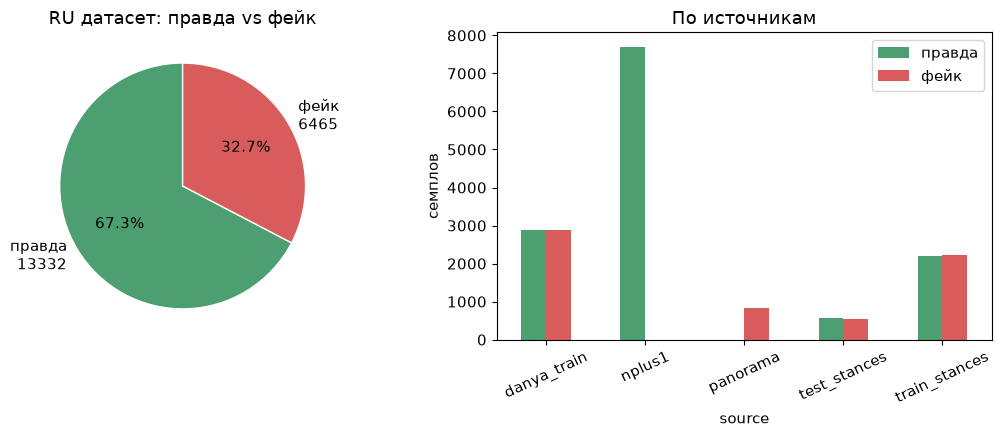

In [10]:
plt.rcParams.update({"figure.figsize": (11, 4.5), "font.size": 11})

fig, axes = plt.subplots(1, 2)

axes[0].pie(
    [n_real, n_fake],
    labels=[f"правда\n{n_real}", f"фейк\n{n_fake}"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4C9F70", "#D95C5C"],
    wedgeprops={"linewidth": 1, "edgecolor": "white"},
)
axes[0].set_title("RU датасет: правда vs фейк")

src_plot = by_src.drop(index="ALL")[["real", "fake"]]
src_plot.plot(
    kind="bar",
    ax=axes[1],
    color=["#4C9F70", "#D95C5C"],
    rot=25,
)
axes[1].set_title("По источникам")
axes[1].set_ylabel("семплов")
axes[1].legend(["правда", "фейк"])

plt.tight_layout()
fig.savefig(PREP / "ru_eda.png", dpi=150)
plt.show()

Ячейка 6. Сохранение

In [11]:
out = PREP / "ru_dataset.csv"
ru.to_csv(out, index=False)
print("сохранено:", out.resolve())

сохранено: C:\GitHub\tg-vm-fake-detector\data\prepared_datasets\ru_dataset.csv
